## 1. Presentation of the Problem

 In this project, I will analyse the Campus Placement Prediction Dataset, available on Kaggle. The dataset contains information about students’ academic background, skills, and extracurricular activities, with the goal of predicting their employability after graduation.
 
The dataset includes several independent variables describing the characteristics of each student. These include demographic variables such as student ID, gender, age, and city tier, as well as academic performance indicators such as Secondary School Certificate (SSC) score, Higher Secondary Certificate (HSC) score, undergraduate degree score, and MBA score. Additional variables describe the educational boards attended, degree specialization, and experience-related factors such as internships, projects, and certifications. The dataset also contains measures of soft and technical skills, communication skills, aptitude test score, number of backlogs, extracurricular activities, and leadership roles.

The dataset includes two potential dependent variables. The first is “placed”, a binary variable indicating whether a student successfully obtained a job after graduation. The second is “salary_lpa”, a continuous variable representing the annual salary (in lakhs per annum) for students who were placed.

The primary objective of this project is to analyse how the different student characteristics influence employability outcomes. In particular, this project will focus on predicting whether a student will be placed after graduation, which represents a binary classification problem. By applying machine learning models, we aim to identify the factors that most strongly affect employability and evaluate how accurately student placement outcomes can be predicted.

Understanding these relationships can help universities, training programs, and students identify the key skills and experiences that improve employment prospects.














## 2. Data Exploration

In [1]:
import sys
assert sys.version_info >= (3, 9)


import sklearn
assert sklearn.__version__ >= "1.0"


import numpy as np
import pandas as pd
import os


%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)


# Precision options
np.set_printoptions(precision=2)
pd.options.display.float_format = '{:.3f}'.format

# Statistical analysis and testing
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Ignore useless warnings (see SciPy issue #5998 and seaborn/matplotlib bug)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")
warnings.filterwarnings(action="ignore", message="The figure layout has changed to tight")




In [2]:

dataset = pd.read_csv("/Users/sophie.reshetnikova/Downloads/campus_placement_data.csv")
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   student_id                  100000 non-null  object 
 1   gender                      100000 non-null  object 
 2   age                         100000 non-null  int64  
 3   city_tier                   100000 non-null  object 
 4   ssc_percentage              100000 non-null  float64
 5   ssc_board                   100000 non-null  object 
 6   hsc_percentage              100000 non-null  float64
 7   hsc_board                   100000 non-null  object 
 8   hsc_stream                  100000 non-null  object 
 9   degree_percentage           100000 non-null  float64
 10  degree_field                100000 non-null  object 
 11  mba_percentage              100000 non-null  float64
 12  specialization              35035 non-null   object 
 13  internships_cou

In [3]:
dataset.describe()

,age,ssc_percentage,hsc_percentage,degree_percentage,mba_percentage,internships_count,projects_count,certifications_count,technical_skills_score,soft_skills_score,aptitude_score,communication_score,work_experience_months,leadership_roles,extracurricular_activities,backlogs,placed,salary_lpa
count,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000
mean,21.556,71.930,71.832,70.186,22.853,1.677,3.295,1.896,5.983,6.413,59.914,6.374,9.964,1.108,2.932,1.046,0.844,9.708
std,1.507,11.867,13.904,15.599,31.610,1.307,1.870,1.775,1.949,2.293,17.773,2.385,11.953,1.207,1.938,1.615,0.363,4.784
min,18.000,40.000,40.000,45.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,21.000,63.870,62.120,58.090,0.000,1.000,2.000,0.000,4.600,4.800,47.900,4.700,0.000,0.000,2.000,0.000,1.000,8.510
50%,21.000,71.920,71.860,69.890,0.000,1.000,3.000,1.000,6.000,6.500,60.000,6.500,3.000,1.000,3.000,0.000,1.000,10.710
75%,22.000,80.030,81.720,81.840,59.330,2.000,4.000,3.000,7.300,8.200,72.100,8.300,20.000,2.000,4.000,2.000,1.000,12.710
max,26.000,100.000,100.000,100.000,100.000,5.000,10.000,8.000,10.000,10.000,100.000,10.000,36.000,5.000,10.000,10.000,1.000,24.220


In [4]:
# Use stratified sampling to create test and training datasets

from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(dataset, dataset["placed"]):
    train_set = dataset.loc[train_index]
    test_set = dataset.loc[test_index]

train_set.shape, test_set.shape

((80000, 26), (20000, 26))

In [5]:
# Checking that stratified sampling worked

train_set["placed"].value_counts() / len(train_set)


placed
1   0.844
0   0.156
Name: count, dtype: float64

In [6]:
test_set["placed"].value_counts() / len(test_set)


placed
1   0.844
0   0.156
Name: count, dtype: float64

In [7]:
dataset["placed"].value_counts() / len(dataset)

placed
1   0.844
0   0.156
Name: count, dtype: float64

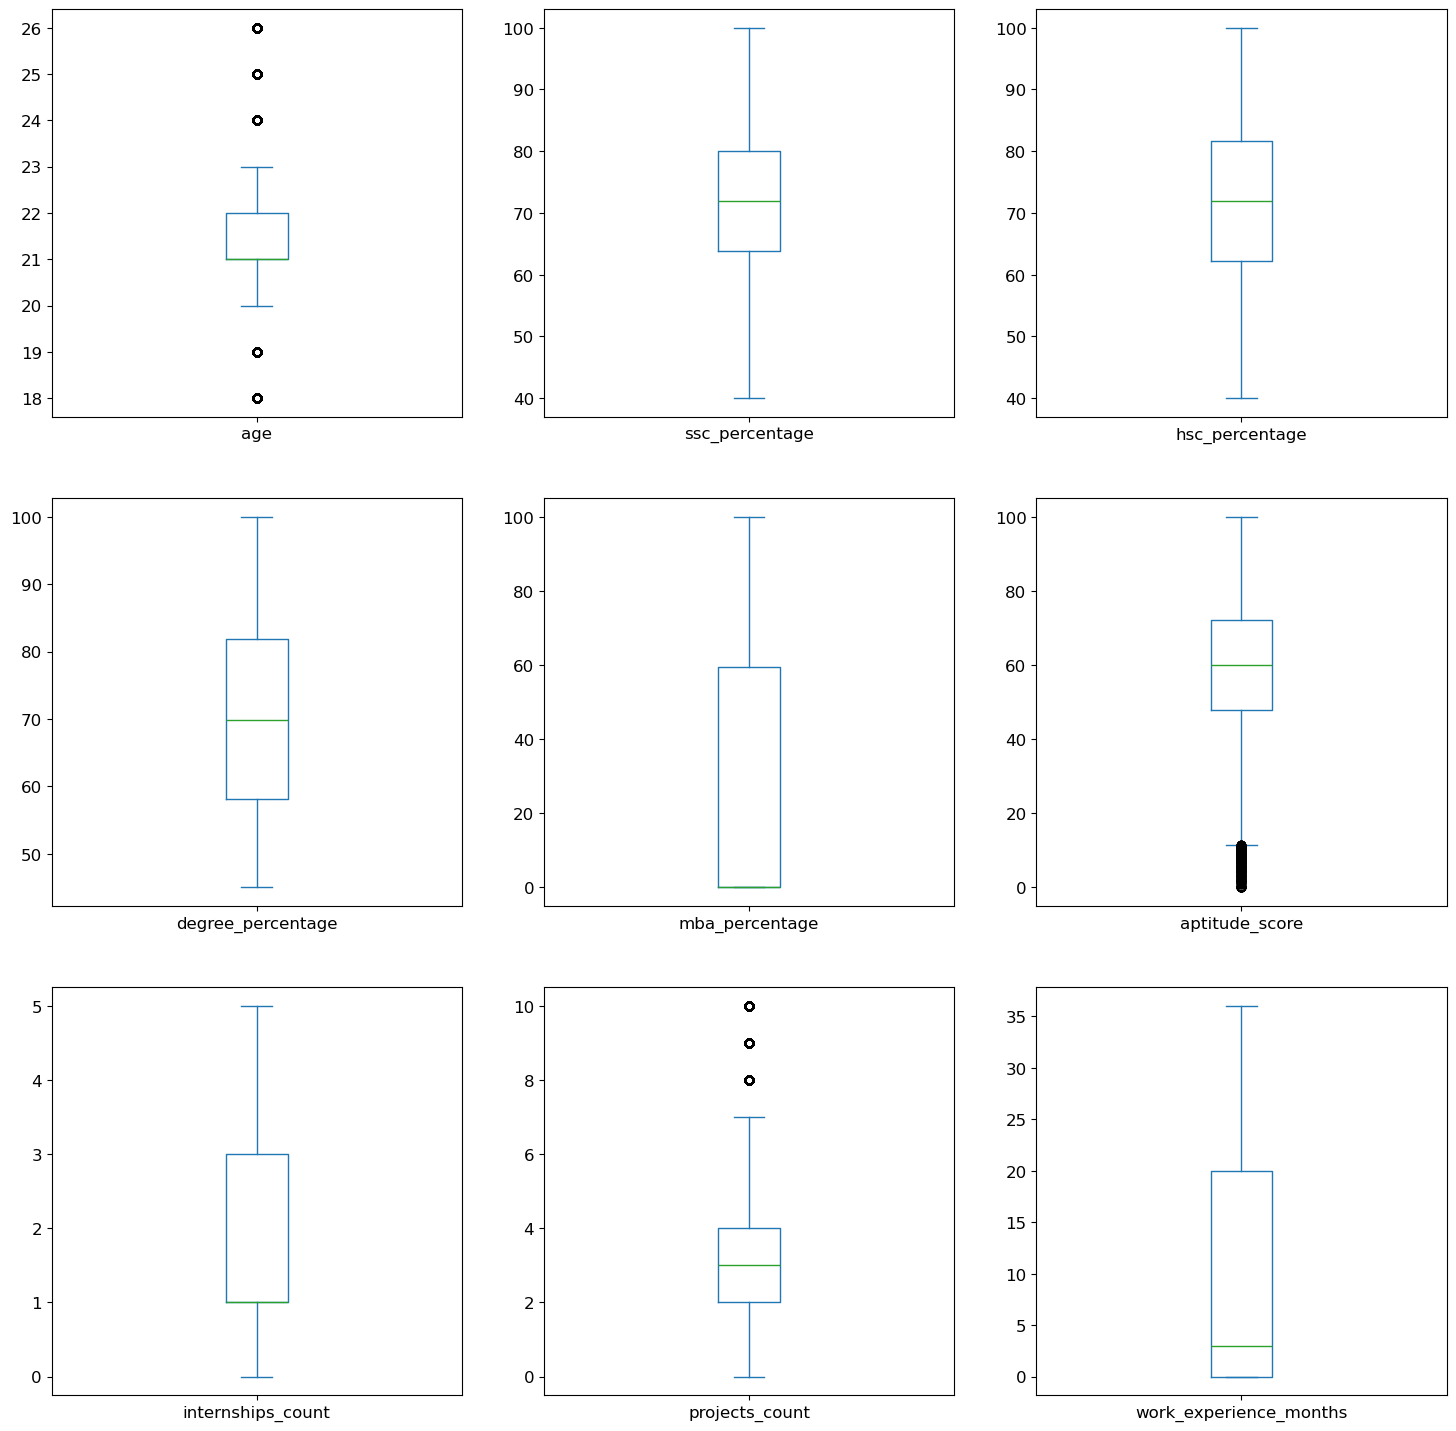

In [8]:
train_set[
    ['age',
     'ssc_percentage',
     'hsc_percentage',
     'degree_percentage',
     'mba_percentage',
     'aptitude_score',
     'internships_count',
     'projects_count',
     'work_experience_months']
].plot.box(subplots=True, layout=(3,3), figsize=(18,18))

plt.show()




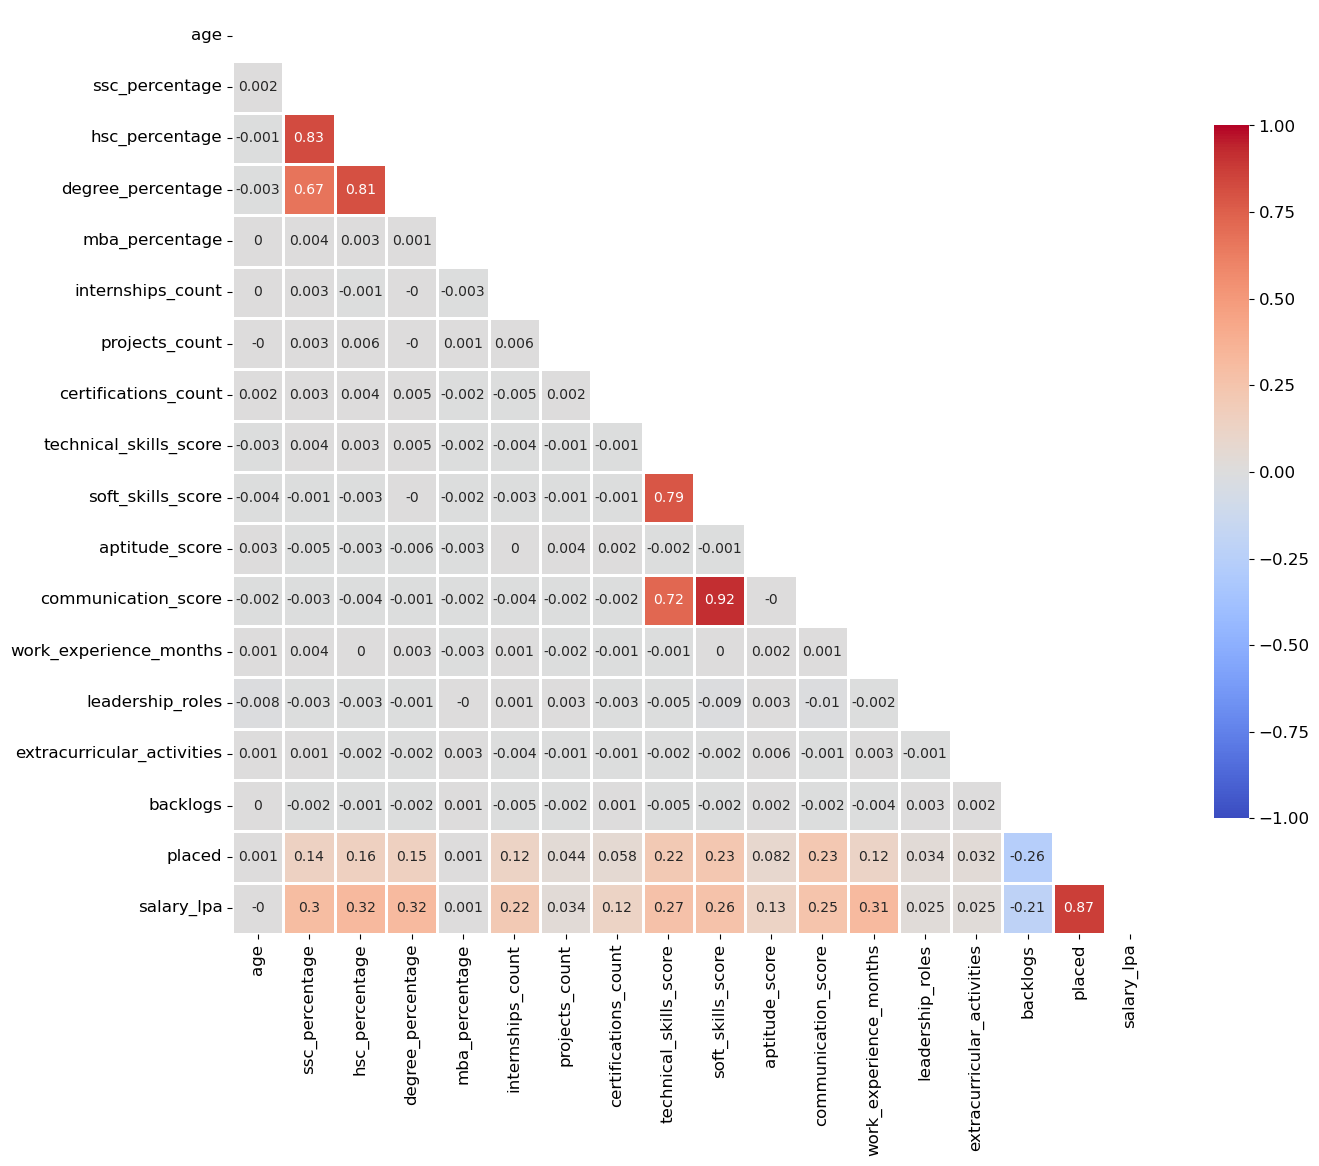

In [12]:

plt.close('all')

train_set_pred = train_set.drop(["student_id", "ssc_board", "hsc_board", "hsc_stream"], axis=1) 
# check for multicolinearity with seaborn heatmap 
# compute the correlation matrix
corr = round(train_set_pred.corr(numeric_only=True),3) 
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(15, 12))
# Draw the heatmap with the mask and correct aspect ratio 
ax = sns.heatmap( corr, 
                 mask=mask,
                 cmap="coolwarm", 
                 vmax=1, 
                 vmin=-1,
                 center=0, 
                 square=True, 
                 linewidths=1, 
                 cbar_kws={"shrink": .75}, 
                 annot=True )




plt.show()







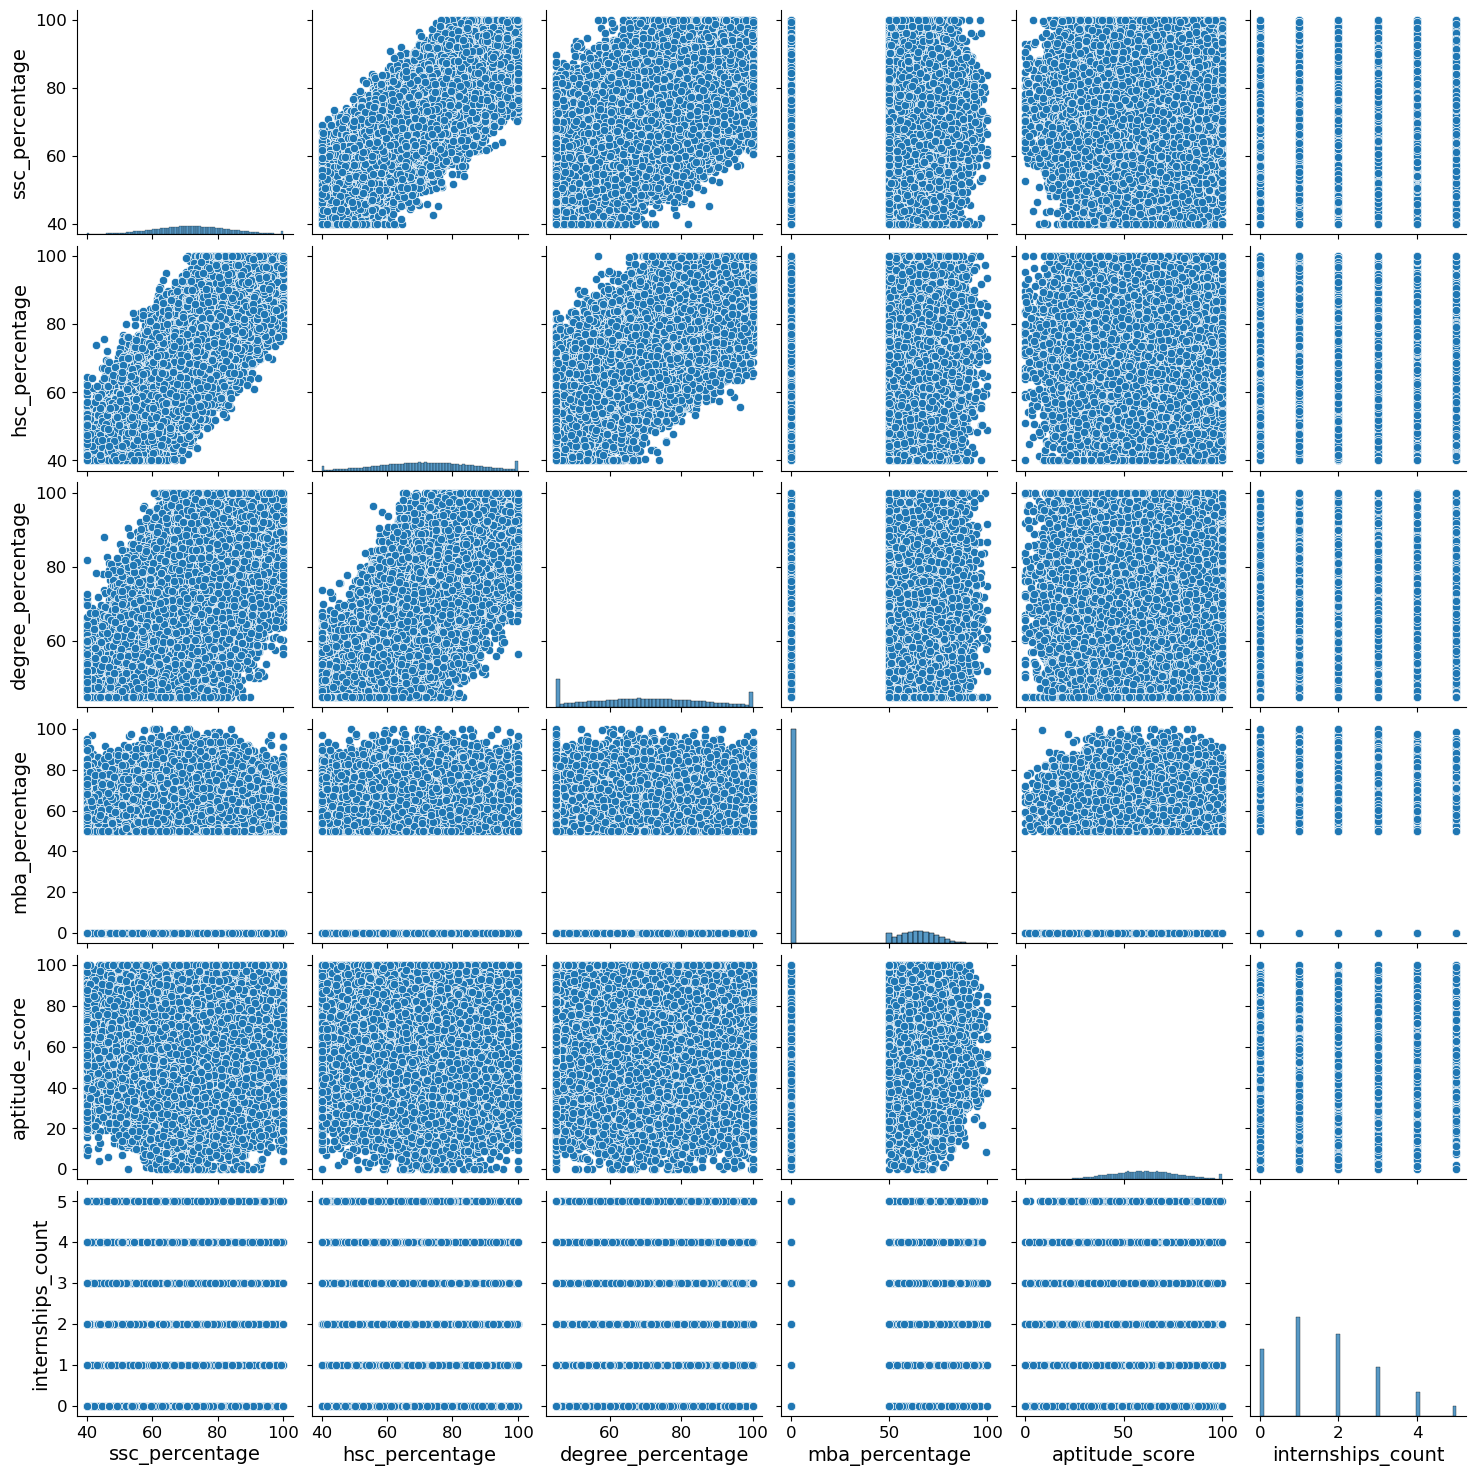

In [9]:
attributes = [
    "ssc_percentage",
    "hsc_percentage",
    "degree_percentage",
    "mba_percentage",
    "aptitude_score",
    "internships_count"
]

sns.pairplot(train_set[attributes])

plt.show()


/var/folders/j5/qr3z4lg16v1cxgpsk6pzzzj80000gn/T/ipykernel_15090/1597702753.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


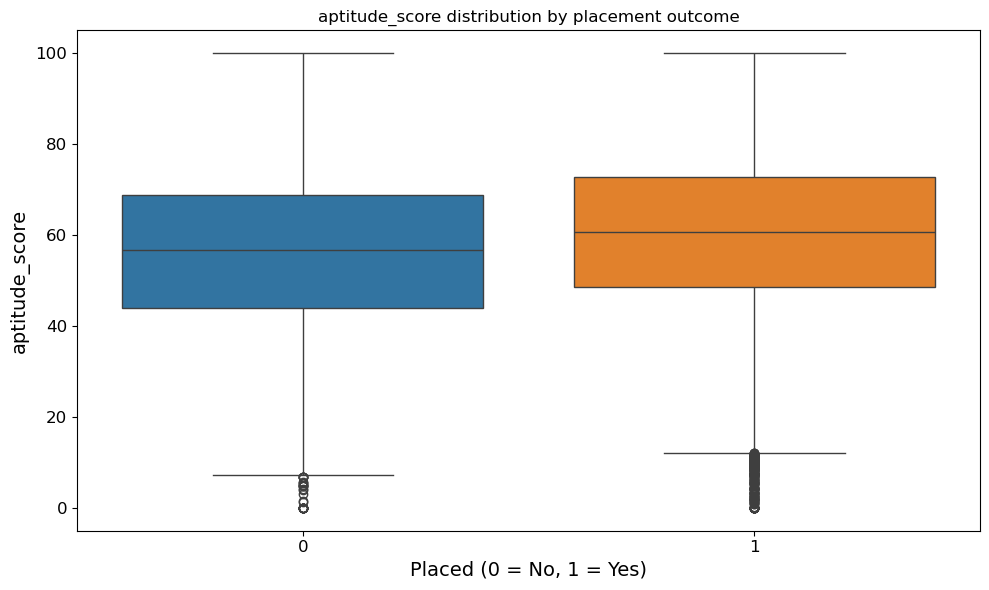

/var/folders/j5/qr3z4lg16v1cxgpsk6pzzzj80000gn/T/ipykernel_15090/1597702753.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


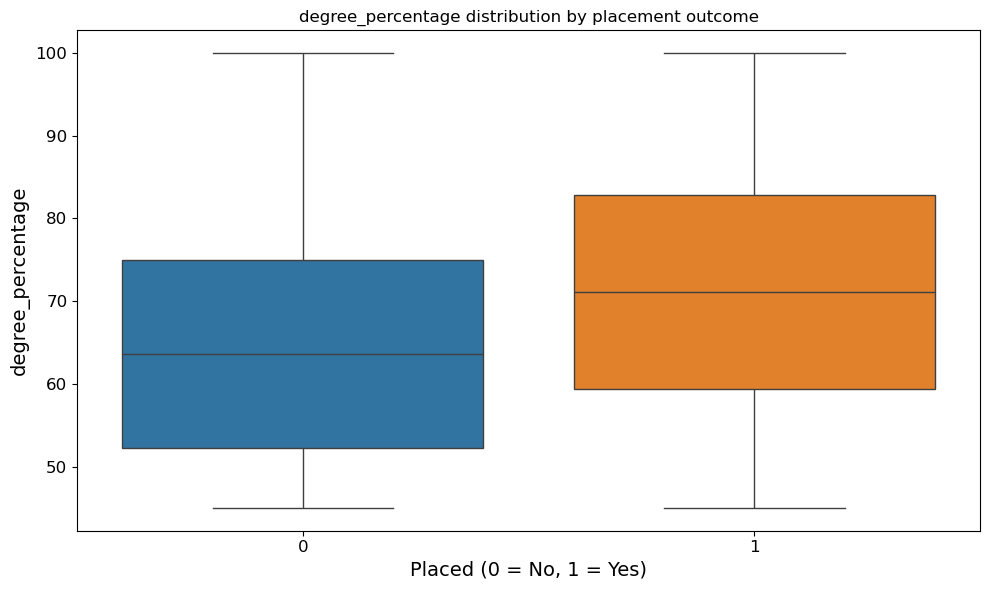

/var/folders/j5/qr3z4lg16v1cxgpsk6pzzzj80000gn/T/ipykernel_15090/1597702753.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


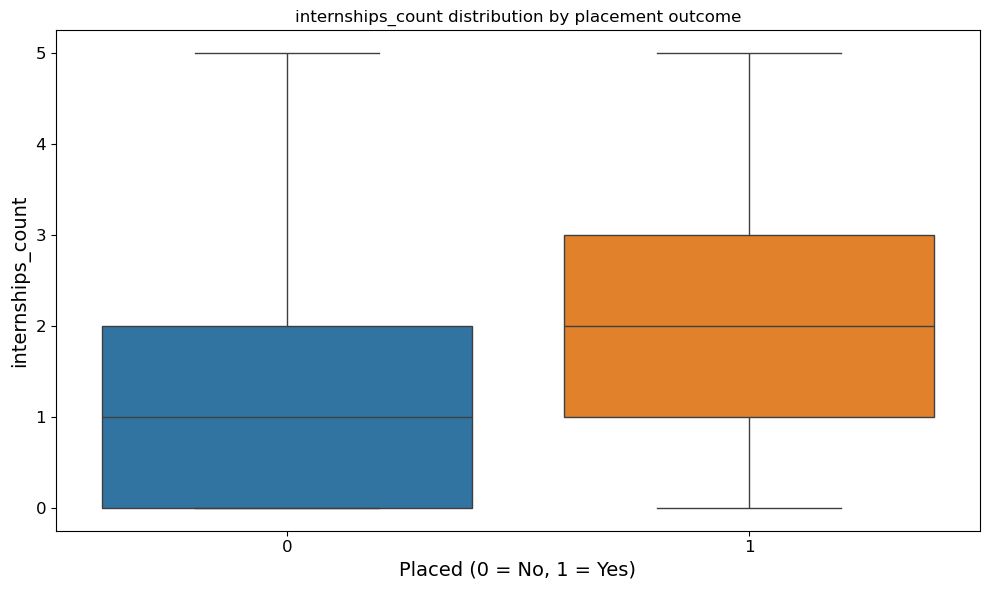

/var/folders/j5/qr3z4lg16v1cxgpsk6pzzzj80000gn/T/ipykernel_15090/1597702753.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


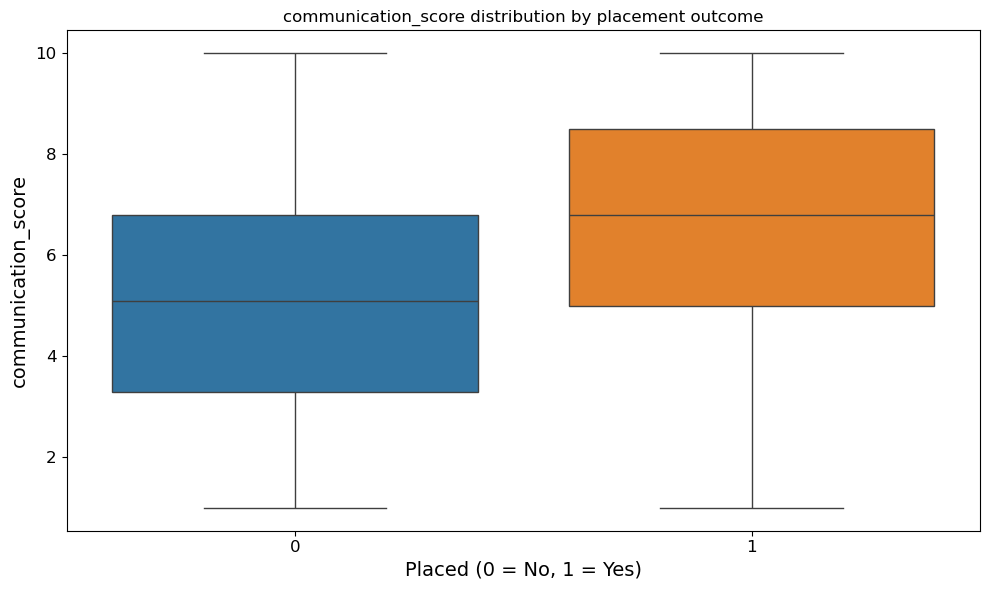

/var/folders/j5/qr3z4lg16v1cxgpsk6pzzzj80000gn/T/ipykernel_15090/1597702753.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


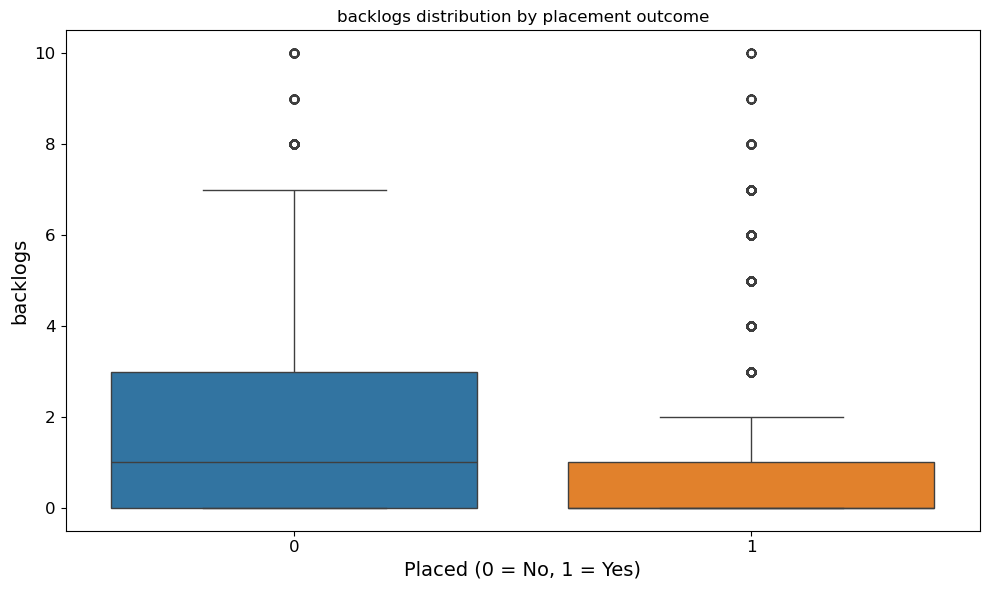

In [9]:
def print_boxplot(
    DataFrame,
    feature,
    figsize=(10,6)
):
    

    df = train_set[[feature, "placed"]].copy()

    plt.subplots(figsize=figsize)

    sns.boxplot(
        data=df,
        x="placed",
        y=feature,
        palette="tab10"
    )

    plt.title(f"{feature} distribution by placement outcome")
    plt.xlabel("Placed (0 = No, 1 = Yes)")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

print_boxplot(train_set, "aptitude_score")
print_boxplot(train_set, "degree_percentage")
print_boxplot(train_set, "internships_count")
print_boxplot(train_set, "communication_score")
print_boxplot(train_set, "backlogs")

### Conclusions of Stage 2 - Data Exploration 

#### Variable Types
The dataset contains the following types of variables:

- Quantitative variables:
age, ssc_percentage, hsc_percentage, degree_percentage, mba_percentage, internships_count, projects_count, certifications_count, technical_skills_score, soft_skills_score, aptitude_score, communication_score, work_experience_months, leadership_roles, extracurricular_activities, backlogs, salary_lpa

- Categorical variables:
gender, city_tier, ssc_board, hsc_board, hsc_stream, degree_field, specialization

- Binary target variable:
placed

The variable student_id is an identifier and will not be used for modelling.

#### Outlier Analysis

Potential outliers in the numerical variables were explored using summary statistics and boxplots. The minimum and maximum values observed for variables such as academic scores, age, and experience-related features fall within realistic ranges. Therefore, no observations were removed from the dataset and no transformations were required at this stage.

#### Multicollinearity

Correlation analysis revealed a high correlation between Secondary School Certificate (SSC), Higher Secondary Certificate (HSC), and Degree grades. Since these variables measure similar aspects of academic performance, it may be beneficial to retain only the most predictive variable to reduce multicollinearity during modelling.

Additionally, soft skills, technical skills, and communication scores show strong correlations, suggesting that these variables capture related aspects of candidate skill levels.

#### Feature Engineering Suggestions
Based on the insights from the exploratory analysis, several additional features may be engineered:

- Experience flag: a binary variable indicating whether a candidate has more than 12 months of work experience.

- Academic weapon flag: a binary feature identifying candidates with high academic performance across school and university grades, higher than 70%.

- Composite skill score: combining soft skills, technical skills, and communication scores into a single skill index representing overall candidate competency.

#### Observed Relationships with Placement

Exploratory analysis suggests that candidates are more likely to be placed if they:

have higher academic grades at school and university,
possess stronger communication and technical skills,
have greater work experience,
and have fewer academic backlogs.

Although these trends are visible in the data, some exceptions are present, indicating that placement outcomes are influenced by multiple factors.



## 3. Data Preparation 

In [10]:
## Look for rows with incomplete values
incomplete_rows = train_set[train_set.isna().any(axis=1)]

pd.set_option('display.max_columns', None)

incomplete_rows.head()


,student_id,gender,age,city_tier,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_stream,degree_percentage,degree_field,mba_percentage,specialization,internships_count,projects_count,certifications_count,technical_skills_score,soft_skills_score,aptitude_score,communication_score,work_experience_months,leadership_roles,extracurricular_activities,backlogs,placed,salary_lpa
93783,STU093784,Male,23,Tier 1,75.540,CBSE,72.910,CBSE,Science,90.820,Business,0.000,NaN,2,2,1,5.000,5.900,58.100,7.100,13,1,2,1,1,13.850
33779,STU033780,Female,23,Tier 2,72.190,CBSE,75.620,State,Science,89.170,Engineering,0.000,NaN,0,3,1,5.100,3.800,35.100,3.400,0,0,2,0,1,8.570
75295,STU075296,Female,21,Tier 2,79.410,CBSE,99.750,State,Science,100.000,Other,0.000,NaN,2,2,2,6.400,5.100,56.800,3.800,0,0,0,0,1,12.510
23680,STU023681,Female,21,Tier 2,63.630,ICSE,75.660,CBSE,Arts,83.890,Business,0.000,NaN,1,1,4,8.200,9.700,56.500,9.000,13,1,7,1,1,11.540
96094,STU096095,Male,18,Tier 1,73.750,State,76.280,State,Arts,75.130,Engineering,0.000,NaN,2,3,0,5.900,7.500,59.900,7.900,23,1,2,0,1,17.030


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer

# Feature engineering function
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    # make a copy of the dataset
    engineered_data = data.copy()
    
    # drop target (we'll keep it separately) and identifier
    engineered_data = engineered_data.drop(columns=["placed", "student_id", "salary_lpa"], errors="ignore")
    
    # fill missing specialization
    engineered_data["specialization"] = engineered_data["specialization"].fillna("None")
    
    # create experience flag (>12 months)
    engineered_data["experience_flag"] = np.where(
        engineered_data["work_experience_months"] > 12, 1, 0
    )
    
    # create high academic achiever flag (>70% in school and university)
    engineered_data["academic_weapon"] = np.where(
        (engineered_data["ssc_percentage"] > 70) &
        (engineered_data["hsc_percentage"] > 70) &
        (engineered_data["degree_percentage"] > 70),
        1, 0
    )
    
    # create composite skill score
    engineered_data["skill_score"] = (
        engineered_data["technical_skills_score"] +
        engineered_data["soft_skills_score"] +
        engineered_data["communication_score"]
    ) / 3
    
    # drop original skill columns
    engineered_data = engineered_data.drop(
        columns=["technical_skills_score", "soft_skills_score", "communication_score", "ssc_percentage", "hsc_percentage","degree_percentage" ]
    )
    
    return engineered_data

# Wrap feature engineering in a transformer
feature_engineer = FunctionTransformer(engineer_features)

# Numerical and categorical features
num_feats = [
    "age",
    "mba_percentage",
    "internships_count",
    "projects_count",
    "certifications_count",
    "aptitude_score",
    "work_experience_months",
    "leadership_roles",
    "extracurricular_activities",
    "backlogs",
    "skill_score",
]

cat_feats = [
    "gender",
    "city_tier",
    "ssc_board",
    "hsc_board",
    "hsc_stream",
    "degree_field",
    "specialization"
]

# Numerical pipeline
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Define ColumnTransformer
column_transformer = ColumnTransformer(
    transformers=[
        ("numerical", num_pipeline, num_feats),
        ("categorical",
         OneHotEncoder(categories="auto", sparse_output=False).set_output(transform="pandas"),
         cat_feats),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
).set_output(transform="pandas")


# Combine feature engineering + preprocessing in one pipeline
full_pipeline = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", column_transformer)
])


#  Apply pipeline to training data
train_data_prepared = full_pipeline.fit_transform(train_set)


# Apply pipeline to test data
test_data_prepared = full_pipeline.transform(test_set)

# Final prepared dataset
train_data_prepared.head()

,age,mba_percentage,internships_count,projects_count,certifications_count,aptitude_score,work_experience_months,leadership_roles,extracurricular_activities,backlogs,skill_score,gender_Female,gender_Male,gender_Other,city_tier_Tier 1,city_tier_Tier 2,city_tier_Tier 3,ssc_board_CBSE,ssc_board_ICSE,ssc_board_State,hsc_board_CBSE,hsc_board_ICSE,hsc_board_State,hsc_stream_Arts,hsc_stream_Commerce,hsc_stream_Science,degree_field_Arts,degree_field_Business,degree_field_Engineering,degree_field_Other,degree_field_Science,specialization_Finance & HR,specialization_Marketing & Finance,specialization_Marketing & HR,specialization_None,experience_flag,academic_weapon
93783,0.963,-0.724,0.245,-0.693,-0.504,-0.102,0.254,-0.090,-0.480,-0.030,-0.125,0.000,1.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1,1
33779,0.963,-0.724,-1.283,-0.158,-0.504,-1.394,-0.834,-0.917,-0.480,-0.649,-1.043,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0,1
73983,-0.368,1.832,-0.519,-0.158,0.059,-1.455,-0.834,-0.917,2.099,1.209,-1.397,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0,0
75295,-0.368,-0.724,0.245,-0.693,0.059,-0.175,-0.834,-0.917,-1.512,-0.649,-0.560,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0,1
76961,-1.033,1.540,2.537,-0.693,-0.504,-0.074,-0.834,-0.090,-0.480,-0.030,0.358,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0,1


In [13]:
# Return placed variable to the datasets
train_set_prepared = pd.concat([train_data_prepared, train_set["placed"]], axis=1)
test_set_prepared = pd.concat([test_data_prepared, test_set["placed"]], axis=1)


### Conclusions of Stage 3 - Data Preparation

#### Missing Values 
Missing value analysis shows that the dataset is largely complete. The only variable containing missing values is specialization. These missing values occur because specialization is only relevant for students who pursued an MBA. During feature engineering, these missing values were replaced with the category "None", representing students without a specialization.
After this step, the dataset contained no remaining missing values, therefore no further imputation was required.

#### Transformations Pipeline 
We created a Pipeline handling missing specialization variable, created engineered features like experience_flag, academic_weapon, skill_score based on conclusions from Stage 2. We dropped the unnecessary columns, did scaling for numerical variables and one-hot encoding for categorical variables. We implemented the same changes for the test dataset. With these changes our dataset is now ready for model fitting. 


## 4. Model Selection

In [20]:
# Keeping targets separately 
X_train = train_set.drop(columns=["placed"])
y_train = train_set["placed"]

X_test = test_set.drop(columns=["placed"])
y_test = test_set["placed"]

In [21]:
# Fitting 3 classification models: Linear Regression, Support Vector Machine, K-Nearest Neighbours

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": Pipeline([
        ("preprocessing", full_pipeline),
        ("model", LogisticRegression())
    ]),
    
    "SVM": Pipeline([
        ("preprocessing", full_pipeline),
        ("model", LinearSVC())
    ]),
    
    "KNN": Pipeline([
        ("preprocessing", full_pipeline),
        ("model", KNeighborsClassifier())
    ])
}

In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

f1_class0 = make_scorer(f1_score, pos_label=0)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring=f1_class0)
    
    print(f"{name}")
    print(f"F1 scores (class 0): {scores}")
    print(f"Mean F1 score (class 0): {scores.mean():.4f}")
    print("-" * 30)

Logistic Regression
F1 scores (class 0): [0.36 0.33 0.33 0.34 0.34]
Mean F1 score (class 0): 0.3408
------------------------------
SVM
F1 scores (class 0): [0.29 0.27 0.26 0.26 0.27]
Mean F1 score (class 0): 0.2710
------------------------------
KNN
F1 scores (class 0): [0.27 0.26 0.25 0.26 0.27]
Mean F1 score (class 0): 0.2625
------------------------------


In [22]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

for name, model in models.items():
    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=5)
    
    print(f"{name}")
    print(confusion_matrix(y_train, y_pred_cv))
    print(classification_report(y_train, y_pred_cv))
    print("-" * 40)

Logistic Regression
[[ 2951  9503]
 [ 1908 65638]]
              precision    recall  f1-score   support

           0       0.61      0.24      0.34     12454
           1       0.87      0.97      0.92     67546

    accuracy                           0.86     80000
   macro avg       0.74      0.60      0.63     80000
weighted avg       0.83      0.86      0.83     80000

----------------------------------------
SVM
[[ 2127 10327]
 [ 1114 66432]]
              precision    recall  f1-score   support

           0       0.66      0.17      0.27     12454
           1       0.87      0.98      0.92     67546

    accuracy                           0.86     80000
   macro avg       0.76      0.58      0.60     80000
weighted avg       0.83      0.86      0.82     80000

----------------------------------------
KNN
[[ 2316 10138]
 [ 2873 64673]]
              precision    recall  f1-score   support

           0       0.45      0.19      0.26     12454
           1       0.86      0.96 

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


pipeline = Pipeline([
    ("preprocessing", full_pipeline),
    ("model", LogisticRegression(max_iter=1000))
])


param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

#Grid search with cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring=f1_class0,   
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)


print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)


best_model = grid_search.best_estimator_

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalt

Best Parameters: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV Score: 0.34108333221719744


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### Conclusions of Stage 4 - Model Selection

Logistic Regression was selected as the final model due to its comparable accuracy, better balance between evaluation metrics, and interpretability.




## 5. Evaluation on Test Set

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Accuracy: 0.85535

Confusion Matrix:
[[  689  2425]
 [  468 16418]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.22      0.32      3114
           1       0.87      0.97      0.92     16886

    accuracy                           0.86     20000
   macro avg       0.73      0.60      0.62     20000
weighted avg       0.83      0.86      0.83     20000



In [25]:
# Let's see how the independent variables affect the predictor 

X_train_transformed = full_pipeline.fit_transform(X_train)
feature_names = full_pipeline.named_steps["preprocessing"].get_feature_names_out()
coefficients = best_model.named_steps["model"].coef_[0]
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()

# Sort by importance
coef_df = coef_df.sort_values(by="abs_coef", ascending=False)


coef_df.head(10)

,feature,coefficient,abs_coef
36,academic_weapon,0.977,0.977
10,skill_score,0.824,0.824
9,backlogs,-0.705,0.705
2,internships_count,0.475,0.475
6,work_experience_months,0.353,0.353
5,aptitude_score,0.290,0.290
35,experience_flag,0.262,0.262
28,degree_field_Engineering,0.259,0.259
25,hsc_stream_Science,0.251,0.251
24,hsc_stream_Commerce,0.217,0.217


## 6. Conclusions 

- All three models achieved similar overall accuracy (~84–86%), with Logistic Regression and SVM performing slightly better than KNN. However, accuracy is not an appropriate performance metric for this dataset because it is imbalanced (approximately 84% of observations belong to the positive employment outcome). Therefore, model comparison was based primarily on precision, recall, and F1-score, particularly for the minority class.
- Evaluation using precision, recall, and F1-score showed that all models performed well in predicting the majority class (placed = 1). Performance on the minority class (placed = 0) was significantly weaker across all models.
- Logistic Regression achieved the best balance between precision and recall for the minority class, with a higher F1-score compared to SVM and KNN. SVM showed slightly higher precision but very low recall for the minority class, while KNN performed the worst overall.
- Hyperparameter tuning was performed to optimise the Logistic Regression model. The tuned logistic regression achieved its best performance with relatively weak regularization (C = 10), indicating that the engineered features are informative and stable, allowing the model to generalize well with a strong cross-validated score of 0.92.

- The final Logistic Regression model indicates a good generalisation to unseen data as it achieved a similar accuracy to the cross-validation results. That indicates that the model is not overfitting and can be used on previously unseen data with a guaranteed reliable result. Similarly, the model demonstrated strong performance in predicting the majority class, but weaker performance for the minority class. This indicates a bias toward the majority class due to class imbalance.
- Analysis of model coefficients showed that academic performance, skill-related factors and work experience were the most influential positive predictors of job placements. The number of backlogs had a strong negative effect on employment likelihood, indicating that academic setbacks significantly reduce employability. Overall, the results suggest that practical skills, experience, and consistent academic performance are key drivers of successful emplpoyment outcomes.

- These findings highlight the importance of skill development and practical experience in improving employment chances, while also suggesting that addressing class imbalance could improve the model’s ability to identify at-risk graduates.
